# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** T.J. Smith

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Words
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [5]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


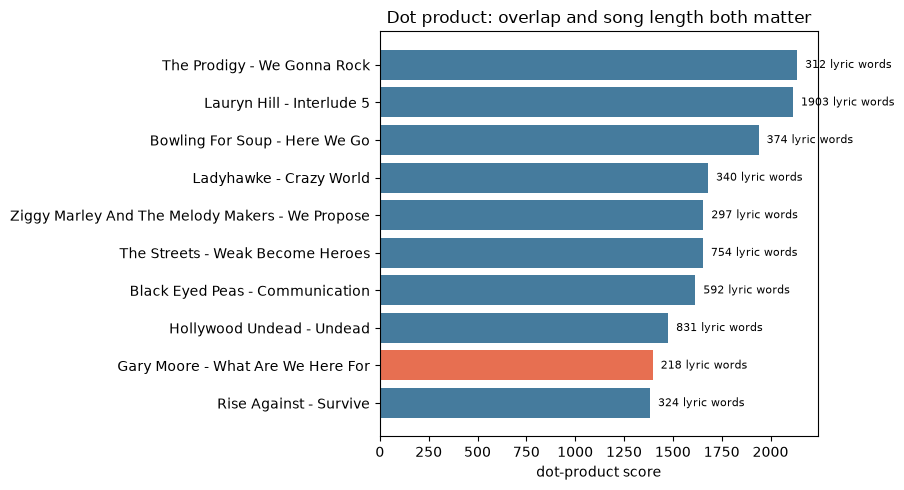

In [6]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

**They seem to be partly rewarding song size, which is confounding the data.**

In [7]:
# Written with assistance from AI
results = top_40.copy()

# This creates 6 columns which display the song match by rank and the dot score by rank.
for rank in range(1,4):
    results[f'dot_match_{rank}']=""
    results[f'dot_score_{rank}']= np.nan

# This performs the comparison of the top three songs for each of the top 40 in each genre and adds the results to the results data frame.
for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]
    # This skips the remainder of the forloop if there are no matches in songs to the top_40 song we are looking at.
    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf

    best_indices = np.argsort(dot_scores)[-3:][::-1] # This sorts the indices in order of dot_score, then selects the top 3, then reverses the order.
    # This assigns the song title to the dot_match_1-3 columns, and the dot scores to the dot_score_1-3 columns of results.
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'dot_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'dot_score_{rank}'] = dot_scores[match_idx]

results.to_csv('top_40_songs_by_genre_results.csv')

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [8]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,4783.12000,5.978900
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,4767.60375,5.959505
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4094.49625,5.118120
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3734.87625,4.668595
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,3704.24125,4.630302
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3635.32375,4.544155
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3594.83250,4.493541
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3565.21250,4.456516
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3550.71125,4.438389
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3531.92375,4.414905


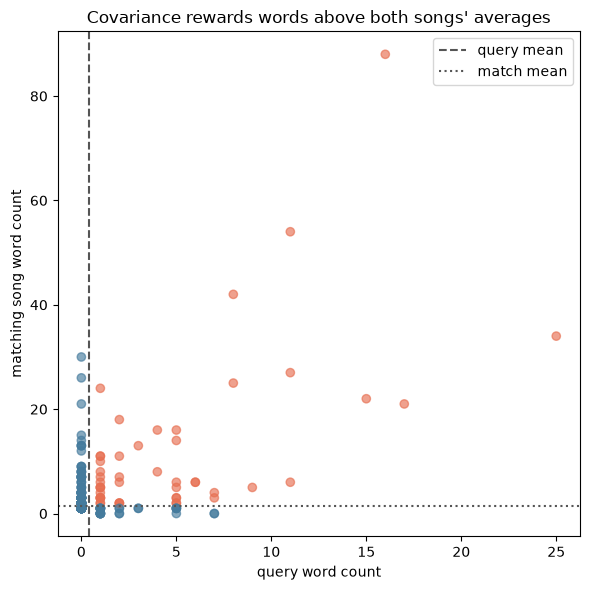

In [9]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

**What changed is there are now songs that have negative covariance, and we are rewarding words that happen above their songs average in order to more heavily weight words that are similar between both songs, rather than just rewarding general word occurences. This helps to reduce the bias of songs with more words in total.**

In [10]:
for rank in range(1,4):
    results[f'cov_match_{rank}']=""
    results[f'cov_score_{rank}']= np.nan

for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    centered_dot_scores = X_centered @ query_centered
    cov_scores = centered_dot_scores / X.shape[1]
    cov_scores[query_idx] = -np.inf    

    best_indices = np.argsort(cov_scores)[-3:][::-1]
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'cov_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'cov_score_{rank}'] = cov_scores[match_idx]

results.to_csv('top_40_songs_by_genre_results.csv')

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [11]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.694141
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.692422
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.682567
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.681100
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.680866
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.677367
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.665229
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.663739
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.663071


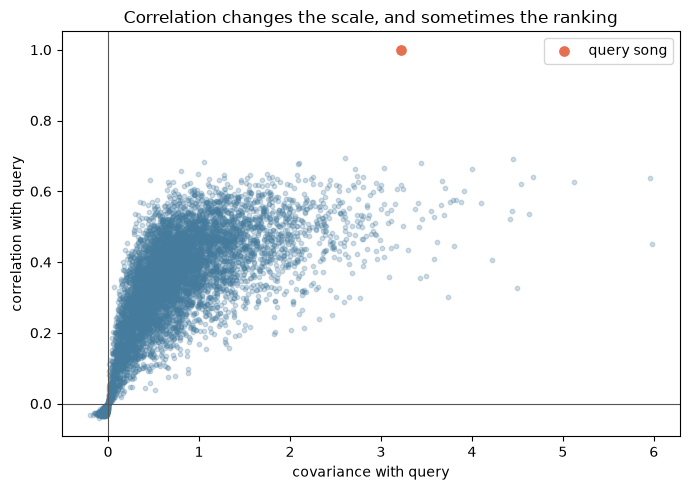

In [12]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

**A song that would move up might be a song that has very few words in total but the words in the song are very similar to the query song. Songs that would move down would be songs that were high in the rankings purely due to their lyrics containing many words artificially inflating their dot score and covariance score.**

In [13]:
for rank in range(1,4):
    results[f'corr_match_{rank}']=""
    results[f'corr_score_{rank}']= np.nan

for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    centered_dot_scores = X_centered @ query_centered
    cov_scores = centered_dot_scores / X.shape[1]

    query_std = query.std()
    X_std = X.std(axis=1)

    denom = X_std * query_std
    corr_scores = np.divide(
        cov_scores,
        denom,
        out=np.zeros_like(cov_scores),
        where=denom != 0,
    )
    corr_scores[query_idx] = -np.inf

    best_indices = np.argsort(corr_scores)[-3:][::-1]
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'corr_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'corr_score_{rank}'] = corr_scores[match_idx]

results.to_csv('top_40_songs_by_genre_results.csv')

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [14]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.708420
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.707237
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.697772
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.696088
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.696041
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.694369
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.682323
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.680961
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.679759


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

**The dot-product seems like a shares lots of raw word mass engine, and the cosine-similarity is a similar songs engine.**

In [15]:
for rank in range(1,4):
    results[f'cossim_match_{rank}']=""
    results[f'cossim_score_{rank}']= np.nan

for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    cossim_scores = cosine_scores(X, query)
    cossim_scores[query_idx] = -np.inf

    best_indices = np.argsort(cossim_scores)[-3:][::-1] 

    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'cossim_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'cossim_score_{rank}'] = cossim_scores[match_idx]

results.to_csv('top_40_songs_by_genre_results.csv')

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

**It looks like the dot and covariance matches are very similar overall in many cases but there is some variance between the two. The correlation and cosine-similarity matches are different from the dot and covariance matches, but are typically the same between themselves (correlation and cosine-similarity have the same output usually).**\
\
**Correlation and Cosine-Similarity are the most in agreement with one another.**\
\
**I think the methods that give the best results are correlation and cosine-similarity. I say this because they are not biased by song-length or sheer word count volume, they are instead based upon a standardized measure of word-smiilarity amoungst the songs. This removes those biases we were worried about.**

In [16]:
results.head(3).T

,0,1,2
track_id,TRVYEUW128F148C08D,TRCXKPC128F92FD04C,TRMMALW128F92FD049
song_id,SOFCCWD12AF72A6BC0,SOEFNXT12AB017E829,SOVUCRS12A58A7D207
artist_id,ARXPPEY1187FB51DF4,ARZENOX1187B98A645,ARZENOX1187B98A645
artist_name,Michael Jackson,John Mayer,John Mayer
song_title,All The Things You Are,Vultures,Out Of My Mind
genre,blues,blues,blues
dot_match_1,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5
dot_score_1,3570.0,3132.0,4597.0
dot_match_2,I'm A Winner (Amended Album Version),Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...
dot_score_2,2865.0,3012.0,3722.0


## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	times IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [17]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

In [18]:
for rank in range(1,4):
    results[f'dotTFIDF_match_{rank}']=""
    results[f'dotTFIDF_score_{rank}']= np.nan
for rank in range(1,4):
    results[f'covTFIDF_match_{rank}']=""
    results[f'covTFIDF_score_{rank}']= np.nan
for rank in range(1,4):
    results[f'corrTFIDF_match_{rank}']=""
    results[f'corrTFIDF_score_{rank}']= np.nan
for rank in range(1,4):
    results[f'cossimTFIDF_match_{rank}']=""
    results[f'cossimTFIDF_score_{rank}']= np.nan

for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = TFIDF[query_idx]


#Dot Score Assignment
    dot_scores = TFIDF @ query
    dot_scores[query_idx] = -np.inf

    best_indices = np.argsort(dot_scores)[-3:][::-1] # This sorts the indices in order of dot_score, then selects the top 3, then reverses the order.
    # This assigns the song title to the dot_match_1-3 columns, and the dot scores to the dot_score_1-3 columns of results.
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'dotTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'dotTFIDF_score_{rank}'] = dot_scores[match_idx]

#Cov Score Assignment
    query_centered = query - query.mean()
    TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)
    centered_dot_scores = TFIDF_centered @ query_centered
    cov_scores = centered_dot_scores / TFIDF.shape[1]
    cov_scores[query_idx] = -np.inf    

    best_indices = np.argsort(cov_scores)[-3:][::-1]
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'covTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'covTFIDF_score_{rank}'] = cov_scores[match_idx]

#Corr Score Assignment
    query_std = query.std()
    TFIDF_std = TFIDF.std(axis=1)
    denom = TFIDF_std * query_std
    corr_scores = np.divide(
        cov_scores,
        denom,
        out=np.zeros_like(cov_scores),
        where=denom != 0,
    )
    corr_scores[query_idx] = -np.inf

    best_indices = np.argsort(corr_scores)[-3:][::-1]
    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'corrTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'corrTFIDF_score_{rank}'] = corr_scores[match_idx]


#Cossim Score Assignment
    cossim_scores = cosine_scores(TFIDF, query)
    cossim_scores[query_idx] = -np.inf

    best_indices = np.argsort(cossim_scores)[-3:][::-1] 

    for rank, match_idx in enumerate(best_indices, start=1):
        results.loc[row_number, f'cossimTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        results.loc[row_number, f'cossimTFIDF_score_{rank}'] = cossim_scores[match_idx]

results.to_csv('top_40_songs_by_genre_results_TFIDF.csv')

**The idf of common words is very low (.29 for I), but the idf for rare words (like doo) is very high (5.73 for doo). This gives a lot of weight to uncommon words.**\
\
**The TFIDF based reccomendations are different in most cases from the original recommendations. They follow the same pattern amongst themselves as the X based recommendations did (correlation and cosine-similarity are the same usually, and are different from dot and covariance scores completely in most cases).**

In [19]:
columns = ['artist_name', 'song_title',
       'dot_match_1', 'dotTFIDF_match_1', 'dot_score_1', 'dotTFIDF_score_1',
       'cov_match_1', 'covTFIDF_match_1','cov_score_1', 'covTFIDF_score_1',
       'corr_match_1', 'corrTFIDF_match_1','corr_score_1',  'corrTFIDF_score_1',
       'cossim_match_1', 'cossimTFIDF_match_1','cossim_score_1',  'cossimTFIDF_score_1']
results[columns].head(3).T

,0,1,2
artist_name,Michael Jackson,John Mayer,John Mayer
song_title,All The Things You Are,Vultures,Out Of My Mind
dot_match_1,Interlude 5,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Interlude 5
dotTFIDF_match_1,Happy Boys & Girls,Interlude 5,Interlude 5
dot_score_1,3570.0,3132.0,4597.0
dotTFIDF_score_1,108.95266,246.482582,178.619038
cov_match_1,Interlude 5,I Mean (I Don't Mean It),Interlude 5
covTFIDF_match_1,Happy Boys & Girls,Fire and Heights,If I Had
cov_score_1,4.1382,3.505269,5.32765
covTFIDF_score_1,0.114612,0.149202,0.151702


## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


## 1

In [24]:
scores = top_40.copy()

n = 3
#Set up columns in scores
for rank in range(1,n+1):
    scores[f'dot_match_{rank}']=""
    scores[f'dot_genre_{rank}']=""
    scores[f'dot_score_{rank}']= np.nan
    scores[f'cossim_match_{rank}']=""
    scores[f'cossim_genre_{rank}']=""
    scores[f'cossim_score_{rank}']=np.nan
    scores[f'cossimTFIDF_match_{rank}']=""
    scores[f'cossimTFIDF_genre_{rank}']=""
    scores[f'cossimTFIDF_score_{rank}']=np.nan

#Set up columns for hits
scores['dot_hits'] = 0
scores['cossim_hits'] = 0
scores['cossimTFIDF_hits'] = 0

#initialize for loop to go through each song in the top_40 list
for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    queryTFIDF = TFIDF[query_idx]
    queryartid = songs.loc[query_idx,'artist_id']

    #Dot Score Assignment
    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf
    dot_scores[songs['artist_id'] == queryartid] = -np.inf

    best_indices = np.argsort(dot_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'dot_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'dot_score_{rank}'] = dot_scores[match_idx]
        scores.loc[row_number, f'dot_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'dot_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'dot_hits'] += 1

    #Cossim Score Assignment
    cossim_scores = cosine_scores(X, query)
    cossim_scores[query_idx] = -np.inf
    cossim_scores[songs['artist_id'] == queryartid] = -np.inf

    best_indices = np.argsort(cossim_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'cossim_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'cossim_score_{rank}'] = cossim_scores[match_idx]
        scores.loc[row_number, f'cossim_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'cossim_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'cossim_hits'] += 1

    #TFIDF Cossim Score Assignment
    cossimTFIDF_scores = cosine_scores(TFIDF, queryTFIDF)
    cossimTFIDF_scores[query_idx] = -np.inf
    cossimTFIDF_scores[songs['artist_id'] == queryartid] = -np.inf

    best_indices = np.argsort(cossimTFIDF_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'cossimTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'cossimTFIDF_score_{rank}'] = cossimTFIDF_scores[match_idx]
        scores.loc[row_number, f'cossimTFIDF_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'cossimTFIDF_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'cossimTFIDF_hits'] += 1



In [25]:
meanofhitsdot = scores['dot_hits'].mean()/n
meanofhitscosim = scores['cossim_hits'].mean()/n
meanofhitstcosim = scores['cossimTFIDF_hits'].mean()/n
print(f'Dot Hits Mean: {meanofhitsdot:.2f}\nCos-Sim Hits Mean: {meanofhitscosim:.2f}\nCos-Sim with TFIDF Hits Mean: {meanofhitstcosim:.2f}')

Dot Hits Mean: 0.09
Cos-Sim Hits Mean: 0.19
Cos-Sim with TFIDF Hits Mean: 0.21


## 2

This is a similar system to above, but I added a reward system for songs whos "top_tags" included the name of the query tracks genre, and I added a reward system for songs who's "artist_id" was found in a list of all the artists in the same genre as the query tracks genre. This highly improved the score. I designed it this way because our baseline we are trying to improve is how effective it is at selecting songs of the same genre. I noticed that the top_tags variable often contained the genre name and other information (which could be used in a further improved model). I also thought that in my experience, songs are often recommended to you because you like similar artists. I decided that "similar" here meant artists who compose songs in the same genre. Thus, I added the two reward metrics which multiplied their scores (from dot, cossim, or TFIDF cossim) by 1.5 if their top_tags included the query genre, and an additional 1.5 if the artist_id was included in the list of artists from the query genre.

In [26]:
scores = top_40.copy()

n = 3
#Set up columns in scores
for rank in range(1,n+1):
    scores[f'dot_match_{rank}']=""
    scores[f'dot_genre_{rank}']=""
    scores[f'dot_score_{rank}']= np.nan
    scores[f'cossim_match_{rank}']=""
    scores[f'cossim_genre_{rank}']=""
    scores[f'cossim_score_{rank}']=np.nan
    scores[f'cossimTFIDF_match_{rank}']=""
    scores[f'cossimTFIDF_genre_{rank}']=""
    scores[f'cossimTFIDF_score_{rank}']=np.nan

#Set up columns for hits
scores['dot_hits'] = 0
scores['cossim_hits'] = 0
scores['cossimTFIDF_hits'] = 0

#initialize for loop to go through each song in the top_40 list
for row_number, song_id in enumerate(top_40['song_id']):
    matches = songs.index[songs['song_id'] == song_id]

    if len(matches) ==0:
        continue

    query_idx = matches[0]
    query = X[query_idx]
    queryTFIDF = TFIDF[query_idx]
    queryartid = songs.loc[query_idx,'artist_id']
    querytags = songs.loc[query_idx,'top_tags'].split('; ')
    artistgenrelist = songs[songs['genre']==songs.loc[query_idx,'genre']]['artist_id'].unique()

    #Dot Score Assignment
    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf
    dot_scores[songs['artist_id'] == queryartid] = -np.inf
    dot_scores[songs['genre'].isin(querytags)] *= 1.5
    dot_scores[songs['artist_id'].isin(artistgenrelist)] *= 1.5

    best_indices = np.argsort(dot_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'dot_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'dot_score_{rank}'] = dot_scores[match_idx]
        scores.loc[row_number, f'dot_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'dot_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'dot_hits'] += 1

    #Cossim Score Assignment
    cossim_scores = cosine_scores(X, query)
    cossim_scores[query_idx] = -np.inf
    cossim_scores[songs['artist_id'] == queryartid] = -np.inf
    cossim_scores[songs['genre'].isin(querytags)] *= 1.5
    cossim_scores[songs['artist_id'].isin(artistgenrelist)] *= 1.5

    best_indices = np.argsort(cossim_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'cossim_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'cossim_score_{rank}'] = cossim_scores[match_idx]
        scores.loc[row_number, f'cossim_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'cossim_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'cossim_hits'] += 1

    #TFIDF Cossim Score Assignment
    cossimTFIDF_scores = cosine_scores(TFIDF, queryTFIDF)
    cossimTFIDF_scores[query_idx] = -np.inf
    cossimTFIDF_scores[songs['artist_id'] == queryartid] = -np.inf
    cossimTFIDF_scores[songs['genre'].isin(querytags)] *= 1.5
    cossimTFIDF_scores[songs['artist_id'].isin(artistgenrelist)] *= 1.5

    best_indices = np.argsort(cossimTFIDF_scores)[-n:][::-1] 
    for rank, match_idx in enumerate(best_indices, start=1):
        scores.loc[row_number, f'cossimTFIDF_match_{rank}'] = (
            songs.loc[match_idx, 'song_title']
        )
        scores.loc[row_number, f'cossimTFIDF_score_{rank}'] = cossimTFIDF_scores[match_idx]
        scores.loc[row_number, f'cossimTFIDF_genre_{rank}'] = songs.loc[match_idx, 'genre']

    for rank in range(1,n+1):
        if (scores.loc[row_number,f'cossimTFIDF_genre_{rank}'] == songs.loc[query_idx,'genre']):
            scores.loc[row_number,'cossimTFIDF_hits'] += 1



In [27]:
meanofhitsdot = scores['dot_hits'].mean()/n
meanofhitscosim = scores['cossim_hits'].mean()/n
meanofhitstcosim = scores['cossimTFIDF_hits'].mean()/n
print(f'Dot Hits Mean: {meanofhitsdot:.2f}\nCos-Sim Hits Mean: {meanofhitscosim:.2f}\nCos-Sim with TFIDF Hits Mean: {meanofhitstcosim:.2f}')

Dot Hits Mean: 0.50
Cos-Sim Hits Mean: 0.86
Cos-Sim with TFIDF Hits Mean: 0.85
